In [4]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=Warning)

In [5]:
df=pd.read_csv("stock_price_cleaned.csv")
df

,Open,High,Low,Close,Adj Close,Volume,Close_Lag1,MA7,MA21,Pct_Change,Daily_Return,Volatility,DayOfWeek
0,0.002471,0.002178,0.002495,0.001794,0.001464,0.111997,0.001984,0.002175,0.001094,1.000000,0.311731,1.000000,0
1,0.002977,0.001567,0.003006,0.001794,0.001464,0.111997,0.001794,0.002018,0.001115,0.512878,0.490115,0.677942,1
2,0.003056,0.002183,0.003086,0.002160,0.001762,0.080695,0.001794,0.001891,0.001162,0.779732,0.838960,0.749709,2
3,0.003522,0.002366,0.003348,0.002235,0.001823,0.099359,0.002160,0.001879,0.001258,0.417420,0.559800,0.586343,3
4,0.002898,0.002017,0.002899,0.001812,0.001478,0.042650,0.002235,0.001761,0.001334,0.604195,0.098586,0.577236,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4738,1.000000,1.000000,1.000000,1.000000,1.000000,0.255528,1.000000,1.000000,1.000000,0.510258,0.515420,0.348480,3
4739,1.000000,1.000000,1.000000,1.000000,1.000000,0.296028,1.000000,1.000000,1.000000,0.447888,0.497408,0.272880,4
4740,1.000000,1.000000,1.000000,1.000000,1.000000,0.213286,1.000000,1.000000,1.000000,0.294316,0.367981,0.256892,0
4741,1.000000,1.000000,1.000000,1.000000,1.000000,0.287378,1.000000,1.000000,1.000000,0.264088,0.282763,0.223052,1


In [6]:
df.columns.tolist()

['Open',
 'High',
 'Low',
 'Close',
 'Adj Close',
 'Volume',
 'Close_Lag1',
 'MA7',
 'MA21',
 'Pct_Change',
 'Daily_Return',
 'Volatility',
 'DayOfWeek']

In [7]:
features=['Open','High','Low','Volume','Close_Lag1','MA7','MA21','Pct_Change','Volatility','DayOfWeek']

In [8]:
#close column same as adj close
#daily return column based on future close,so leaks target info
# so we are not using close and daily return column in modelling

In [9]:
X=df[features]
y=df['Adj Close']

In [10]:
#train test split(no shuffling for time series)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=False)


Training: Linear Regression
Training: Ridge
Training: Lasso
Training: ElasticNet
Training: Decision Tree
Training: Random Forest
Training: Gradient Boosting
Training: SVR
Training: KNN

Model Evaluation Results:
               Model       MAE      RMSE         R2  \
0  Linear Regression  0.043726  0.049917   0.897015   
1              Ridge  0.044086  0.050352   0.895213   
3         ElasticNet  0.047649  0.053537   0.881536   
2              Lasso  0.078551  0.082228   0.720541   
4      Decision Tree  0.314184  0.349657  -4.053207   
5      Random Forest  0.326476  0.360780  -4.379805   
6  Gradient Boosting  0.326666  0.361053  -4.387960   
8                KNN  0.331593  0.364463  -4.490192   
7                SVR  0.546627  0.583908 -13.091946   

                                         Best Params  
0                                            Default  
1                         {'regressor__alpha': 10.0}  
3  {'regressor__alpha': 0.01, 'regressor__l1_rati...  
2                

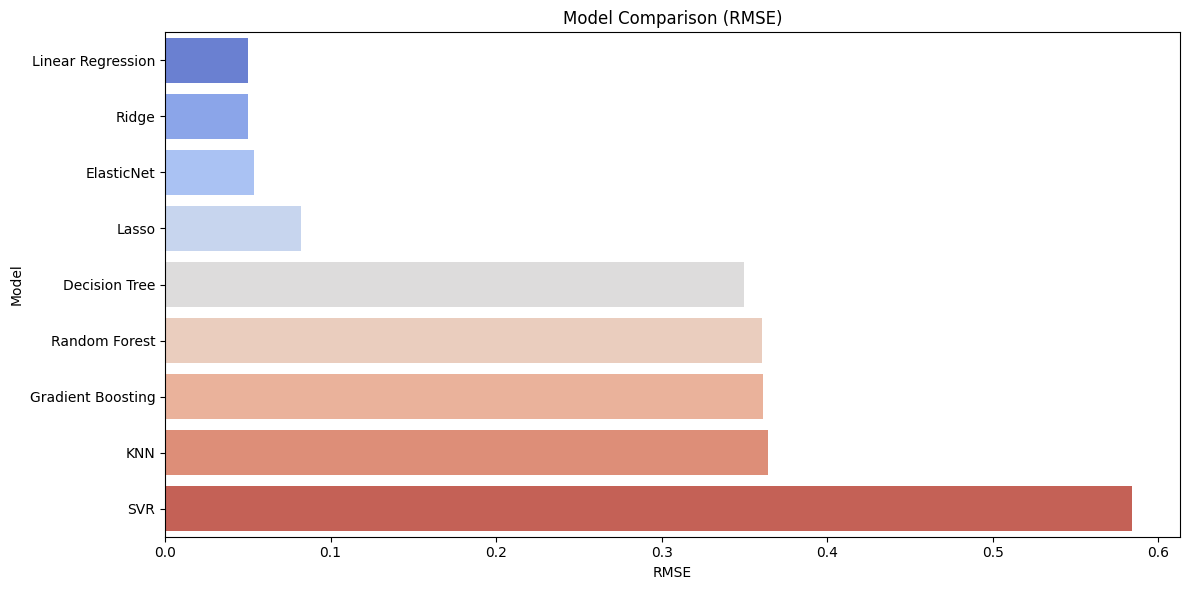

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# ----------------------------
# Define Models & Parameters
# ----------------------------
models = {
    "Linear Regression": (LinearRegression(), {}),
    "Ridge": (Ridge(), {'regressor__alpha': [0.1, 1.0, 10.0]}),
    "Lasso": (Lasso(), {'regressor__alpha': [0.01, 0.1, 1.0]}),
    "ElasticNet": (ElasticNet(), {'regressor__alpha': [0.01, 0.1, 1.0], 'regressor__l1_ratio': [0.1, 0.5, 0.9]}),
    "Decision Tree": (DecisionTreeRegressor(), {'regressor__max_depth': [3, 5, 10, None]}),
    "Random Forest": (RandomForestRegressor(), {'regressor__n_estimators': [50, 100], 'regressor__max_depth': [None, 10]}),
    "Gradient Boosting": (GradientBoostingRegressor(), {'regressor__n_estimators': [50, 100], 'regressor__learning_rate': [0.05, 0.1]}),
    "SVR": (SVR(), {'regressor__C': [0.1, 1, 10], 'regressor__kernel': ['linear', 'rbf']}),
    "KNN": (KNeighborsRegressor(), {'regressor__n_neighbors': [3, 5, 10]})
}

# ----------------------------
# Evaluation Metrics
# ----------------------------
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return mae, rmse, r2

# ----------------------------
# Train & Evaluate All Models
# ----------------------------
results = []

for name, (regressor, param_grid) in models.items():
    print(f"Training: {name}")
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', regressor)
    ])
    
    if param_grid:
        grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        best_params = grid.best_params_
    else:
        pipeline.fit(X_train, y_train)
        best_model = pipeline
        best_params = "Default"

    mae, rmse, r2 = evaluate(best_model, X_test, y_test)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Best Params": best_params
    })

# ----------------------------
# Results Summary
# ----------------------------
results_df = pd.DataFrame(results)
print("\nModel Evaluation Results:")
print(results_df.sort_values(by="RMSE"))

# ----------------------------
# Visualization
# ----------------------------
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df.sort_values('RMSE'), x='RMSE', y='Model', palette='coolwarm')
plt.title("Model Comparison (RMSE)")
plt.tight_layout()
plt.show()
